
===== Linear Regression =====
MAE      : 159.93
RMSE     : 194.38
R2 Score : 0.9950
Accuracy : 98.97%

===== ARIMA =====
MAE      : 242.13
RMSE     : 281.04
R2 Score : 0.9863
Accuracy : 98.60%

PREDICTIONS FUTURES
   Année  LinearRegression     ARIMA
0   2024          22098.02  21971.67
1   2025          23056.97  22837.18
2   2026          24015.92  23683.05
3   2027          24974.87  24509.71
4   2028          25933.82  25317.61
5   2029          26892.77  26107.16


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sar

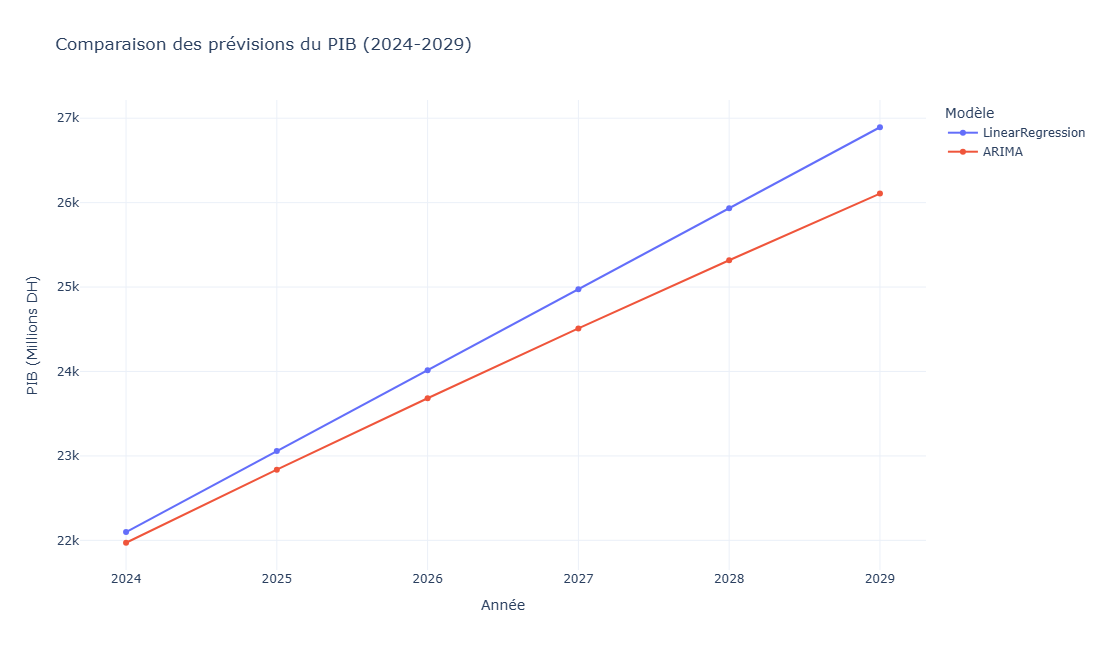

In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.arima.model import ARIMA

# =========================================================
# 1. Charger les données
# =========================================================

df = pd.read_csv(r"../data/PIBRegCour.csv", sep=";")

# Adapter les noms si nécessaire
df = df[["Année", "Valeur"]]

df["Année"] = df["Année"].astype(int)
df["Valeur"] = df["Valeur"].astype(float)

# =========================================================
# 2. Variables
# =========================================================

X = df[["Année"]]
y = df["Valeur"]

# années futures
future_years = np.arange(2024, 2030)
future_X = future_years.reshape(-1, 1)

# =========================================================
# 3. Fonction d'évaluation
# =========================================================

def evaluate_model(name, y_true, y_pred):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    data = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred
    }).dropna()

    mae = mean_absolute_error(data["y_true"], data["y_pred"])
    rmse = np.sqrt(mean_squared_error(data["y_true"], data["y_pred"]))
    r2 = r2_score(data["y_true"], data["y_pred"])

    mape = np.mean(
        np.abs((data["y_true"] - data["y_pred"]) / data["y_true"])
    ) * 100

    accuracy = 100 - mape

    print(f"\n===== {name} =====")
    print(f"MAE      : {mae:.2f}")
    print(f"RMSE     : {rmse:.2f}")
    print(f"R2 Score : {r2:.4f}")
    print(f"Accuracy : {accuracy:.2f}%")
    

# =========================================================
# 4. LINEAR REGRESSION
# =========================================================

lr_model = LinearRegression()

lr_model.fit(X, y)

lr_pred_train = lr_model.predict(X)

evaluate_model(
    "Linear Regression",
    y,
    lr_pred_train
)

lr_future = lr_model.predict(future_X)

# =========================================================
# 6. ARIMA
# =========================================================

serie = df.set_index("Année")["Valeur"]

arima_model = ARIMA(
    serie,
    order=(1,1,1)
)

arima_fit = arima_model.fit()

arima_pred_train = arima_fit.predict(
    start=1,
    end=len(serie)-1,
    typ="levels"
)

# alignement
y_arima = y.iloc[1:]

evaluate_model(
    "ARIMA",
    y_arima,
    arima_pred_train
)

arima_future = arima_fit.forecast(steps=6)

# =========================================================
# 7. Tableau des prévisions
# =========================================================

predictions = pd.DataFrame({
    "Année": future_years,
    "LinearRegression": lr_future.round(2),
    "ARIMA": (arima_future.values).round(2)
})

print("\n==============================")
print("PREDICTIONS FUTURES")
print("==============================")

print(predictions)


# ==========================================
# GRAPHIQUES LINEAR REGRESSION ET ARIMA
# ==========================================
figure_pib = px.line(
    predictions,
    x="Année",
    y=["LinearRegression", "ARIMA"],
    markers=True,
    title="Comparaison des prévisions du PIB (2024-2029)"
)

figure_pib.update_layout(
    template="plotly_white",
    xaxis_title="Année",
    yaxis_title="PIB (Millions DH)",
    legend_title="Modèle",
    height=650
)

figure_pib.show()
